<a href="https://colab.research.google.com/github/Srivarshini0206/Dental-Radiograph-Analysis-System/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install segment-anything
!pip install opencv-python matplotlib
!pip install torch torchvision


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-05 14:16:15--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.162.103.11, 3.162.103.54, 3.162.103.89, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.162.103.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  28.7MB/s    in 7.0s    

2026-03-05 14:16:22 (50.8 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
import matplotlib.pyplot as plt

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

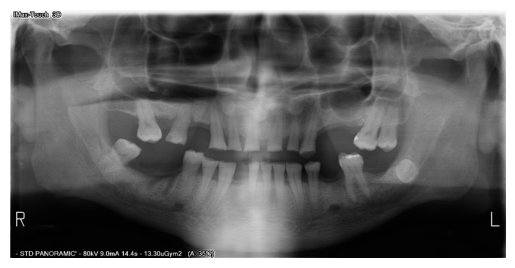

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/Dental/opg_images/1.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image (VERY IMPORTANT)
image = cv2.resize(image, (1024, 512))

plt.imshow(image)
plt.axis("off")

In [ ]:
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=8,
    pred_iou_thresh=0.9,
    stability_score_thresh=0.92,
    crop_n_layers=0
)

In [ ]:
masks = mask_generator.generate(image)

print(len(masks))

24


(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

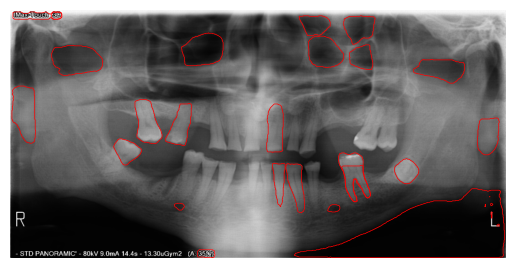

In [ ]:
import numpy as np

plt.imshow(image)

for mask in masks:
    m = mask["segmentation"]
    plt.contour(m, colors="red", linewidths=0.5)

plt.axis("off")

In [ ]:
mask_image = np.zeros(image.shape[:2], dtype=np.uint8)

for i, mask in enumerate(masks):
    mask_image[mask["segmentation"]] = i + 1

(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

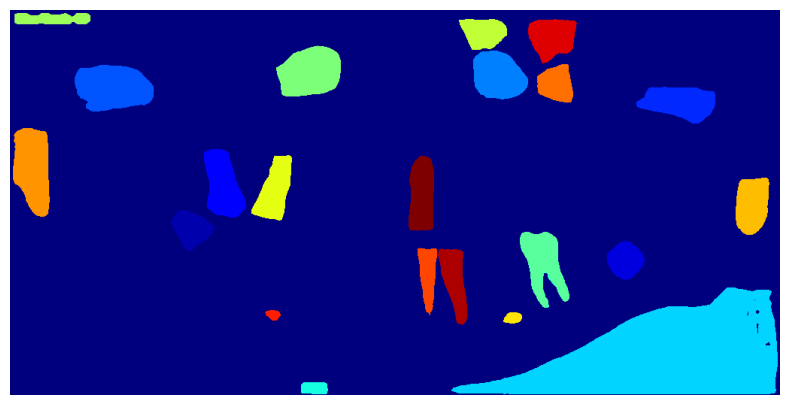

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(mask_image, cmap="jet")
plt.axis("off")

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Dental/masks", exist_ok=True)

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Dental/masks"))

['1_mask.png']


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import torch

input_folder = "/content/drive/MyDrive/Dental/opg_images"
output_folder = "/content/drive/MyDrive/Dental/masks"

os.makedirs(output_folder, exist_ok=True)

# only image files
files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith((".jpg",".png",".jpeg"))])

batch_size = 50

print("Total images:", len(files))

# ensure SAM runs on GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device=device)

print("Using device:", device)

for batch_start in range(0, len(files), batch_size):

    batch_files = files[batch_start: batch_start + batch_size]

    print(f"\nProcessing Batch {batch_start//batch_size + 1}")

    for file in tqdm(batch_files):

        save_name = file.split(".")[0] + "_mask.png"
        save_path = os.path.join(output_folder, save_name)

        # skip already processed images
        if os.path.exists(save_path):
            continue

        image_path = os.path.join(input_folder, file)

        image = cv2.imread(image_path)

        # SMALLER IMAGE = MUCH FASTER
        image = cv2.resize(image, (384,192))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # generate SAM masks
        masks = mask_generator.generate(image)

        mask_image = np.zeros(image.shape[:2], dtype=np.uint8)

        # limit masks heavily
        for i, mask in enumerate(masks[:15]):
            mask_image[mask["segmentation"]] = i + 1

        cv2.imwrite(save_path, mask_image)

    print(f"Batch {batch_start//batch_size + 1} completed")

print("\nAll masks generated successfully.")

Total images: 598
Using device: cpu

Processing Batch 1


100%|██████████| 50/50 [27:01<00:00, 32.42s/it]


Batch 1 completed

Processing Batch 2


100%|██████████| 50/50 [45:20<00:00, 54.41s/it]


Batch 2 completed

Processing Batch 3


100%|██████████| 50/50 [44:54<00:00, 53.89s/it]


Batch 3 completed

Processing Batch 4


 40%|████      | 20/50 [18:28<27:31, 55.05s/it]

In [ ]:
import torch
torch.cuda.is_available()

False